In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
env = gym.make("Taxi-v3")

In [3]:
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.9997
epsilon_min = 0.05
episodes = 100000
max_steps = 200
alpha = 0.01

In [4]:
n_actions = env.action_space.n
Q = defaultdict(lambda: np.zeros(n_actions))

In [5]:
episode_rewards = []

In [6]:
def epsilon_greedy(state):
    if random.random() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state])

Monte Carlo Training

In [7]:
for ep in range(episodes):
    state, _ = env.reset()
    episode_data = []
    total_reward = 0
    
    for step in range(max_steps):
        action = epsilon_greedy(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        episode_data.append((state, action, reward))
        total_reward += reward
        state = next_state
        
        if done:
            break
    
    # Every-visit incremental update
    G = 0
    for t in reversed(range(len(episode_data))):
        s, a, r = episode_data[t]
        G = gamma * G + r
        Q[s][a] += alpha * (G - Q[s][a])
    
    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

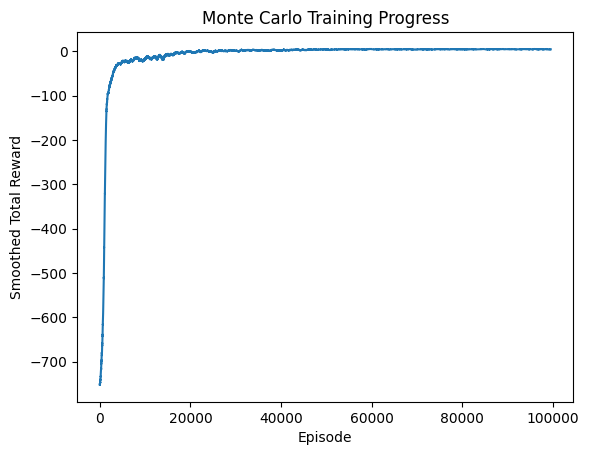

In [8]:
def moving_average(data, window=500):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.plot(moving_average(episode_rewards))
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title("Monte Carlo Training Progress")
plt.show()

In [9]:
def evaluate_mc(env, Q, episodes=200):
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total = 0
        while not done:
            action = np.argmax(Q[state])
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
        rewards.append(total)
    return np.mean(rewards)

print("MC Evaluation Reward:", evaluate_mc(env, Q))

MC Evaluation Reward: 7.53
